In [2]:
! pip install datasets wordcloud transformers --quiet

In [7]:
! pip install "accelerate>=1.1.0"

In [ ]:
import json
import pandas as pd
import re

BUSINESS_FILE = "yelp_academic_dataset_business.json"
REVIEW_FILE   = "yelp_academic_dataset_review.json"

TARGET_CATEGORIES = [
    "Hospitals", "Medical Centers", "Urgent Care",
    "Doctors", "OBGYN", "Pediatricians"
]

print("Finding healthcare businesses...")
hospital_ids = set()

with open(BUSINESS_FILE, "r", encoding="utf8") as f:
    for line in f:
        data = json.loads(line)
        categories = data.get("categories")
        if categories and any(cat in categories for cat in TARGET_CATEGORIES):
            hospital_ids.add(data["business_id"])

print("Healthcare providers found:", len(hospital_ids))

print("Extracting reviews...")
reviews, ratings = [], []

with open(REVIEW_FILE, "r", encoding="utf8") as f:
    for line in f:
        data = json.loads(line)
        if data["business_id"] in hospital_ids:
            reviews.append(data["text"])
            ratings.append(data["stars"])

df = pd.DataFrame({"Review Text": reviews, "Rating": ratings})

# CLEANING
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Review Text"] = df["Review Text"].apply(clean_text)

df = df[df["Review Text"].str.split().str.len() > 8]
df = df.drop_duplicates(subset=["Review Text"])

# LABELING
def assign_label(stars):
    if stars <= 2:
        return 0
    elif stars == 3:
        return 1
    else:
        return 2

df["Label"] = df["Rating"].apply(assign_label)

# 🔥 UPSAMPLE NEUTRAL
neutral_df = df[df["Label"] == 1]

print("Before upsampling:")
print(df["Label"].value_counts())

neutral_upsampled = neutral_df.sample(n=6000, replace=True, random_state=42)

df = pd.concat([
    df[df["Label"] == 0],
    neutral_upsampled,
    df[df["Label"] == 2]
]).reset_index(drop=True)

print("After upsampling:")
print(df["Label"].value_counts())

df.to_csv("hospital_reviews_FINAL.csv", index=False)
print("✅ Dataset ready")

Finding healthcare businesses...
Healthcare providers found: 4524
Extracting reviews...
Before upsampling:
Label
2    40257
0    30238
1     2668
Name: count, dtype: int64
After upsampling:
Label
2    40257
0    30238
1     6000
Name: count, dtype: int64
✅ Dataset ready


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import xgboost as xgb
from transformers import AutoTokenizer, AutoModel

sns.set(style="whitegrid")

MODEL_NAME = "roberta-base"
NUM_LABELS = 3
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

gc.collect()
torch.cuda.empty_cache()

# =========================
# LOAD & BALANCE DATA
# =========================
df = pd.read_csv("hospital_reviews_FINAL.csv")

df_neg = df[df["Label"] == 0]
df_neu = df[df["Label"] == 1]
df_pos = df[df["Label"] == 2]

print("Original Distribution:")
print(df["Label"].value_counts())

def safe_sample(data, n):
    if len(data) >= n:
        return data.sample(n=n, random_state=42)
    else:
        print(f"⚠️ Not enough samples → using replacement for {n}")
        return data.sample(n=n, replace=True, random_state=42)

df_neg = safe_sample(df_neg, 6000)
df_pos = safe_sample(df_pos, 6000)

df_balanced = pd.concat([df_neg, df_neu, df_pos])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced Distribution:")
print(df_balanced["Label"].value_counts())
print("Final Dataset Size:", len(df_balanced))

# =========================
# TRAIN TEST SPLIT
# =========================
texts = df_balanced["Review Text"].astype(str)
labels = df_balanced["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

# =========================
# LOAD ROBERTA
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

# =========================
# EMBEDDING FUNCTION
# =========================
def get_embeddings(texts):
    embeddings = []
    for text in tqdm(texts):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
        embeddings.append(cls_embedding)

    return np.array(embeddings)

# =========================
# GENERATE EMBEDDINGS
# =========================
print("Generating train embeddings...")
X_train_emb = get_embeddings(X_train)

print("Generating test embeddings...")
X_test_emb = get_embeddings(X_test)

# =========================
# XGBOOST MODEL
# =========================
model_xgb = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.07,
    reg_alpha = 1.0,
    reg_lambda = 2.0,
    gamma = 0.5,

    # 🔥 Overfitting control
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric=["mlogloss", "merror"]
)

# =========================
# TRAIN WITH VALIDATION
# =========================
from xgboost.callback import EarlyStopping

model_xgb.fit(
    X_train_emb, y_train,
    eval_set=[(X_train_emb, y_train), (X_test_emb, y_test)],
    verbose=False
)

results = model_xgb.evals_result()
results = model_xgb.evals_result()

# =========================
# LOSS CURVE
# =========================
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("XGBoost Loss Curve")
plt.legend()
plt.savefig("xgb_loss_curve.png")
plt.close()

# =========================
# ACCURACY CURVE
# =========================
train_error = results['validation_0']['merror']
val_error   = results['validation_1']['merror']

train_acc = [1 - e for e in train_error]
val_acc   = [1 - e for e in val_error]

plt.figure()
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy Curve")
plt.legend()
plt.savefig("xgb_accuracy_curve.png")
plt.close()

# =========================
# PREDICTION
# =========================
y_pred = model_xgb.predict(X_test_emb)

print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES)
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_xgb.png")
plt.close()

# =========================
# ROC CURVE
# =========================
y_probs = model_xgb.predict_proba(X_test_emb)
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr, tpr, roc_auc = {}, {}, {}

for i in range(NUM_LABELS):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(NUM_LABELS):
    plt.plot(fpr[i], tpr[i], label=f"{LABEL_NAMES[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (RoBERTa + XGBoost)")
plt.legend()

plt.savefig("roc_curve_xgb.png")
plt.close()

print("🔥 FINAL PIPELINE COMPLETE (WITH CURVES)")
model_xgb.save_model("xgb_model.json")
tokenizer.save_pretrained("roberta_local")
model.save_pretrained("roberta_local")

Device: cuda
Original Distribution:
Label
2    40257
0    30238
1     6000
Name: count, dtype: int64

Balanced Distribution:
Label
0    6000
1    6000
2    6000
Name: count, dtype: int64
Final Dataset Size: 18000


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10419.12it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Generating train embeddings...


100%|██████████| 14400/14400 [03:08<00:00, 76.34it/s] 


Generating test embeddings...


100%|██████████| 3600/3600 [00:35<00:00, 100.63it/s]


              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1200
     Neutral       0.80      0.83      0.82      1200
    Positive       0.94      0.90      0.92      1200

    accuracy                           0.86      3600
   macro avg       0.86      0.86      0.86      3600
weighted avg       0.86      0.86      0.86      3600

🔥 FINAL PIPELINE COMPLETE (WITH CURVES)


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]


In [2]:
! pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 6.7 MB/s eta 0:00:16
    --------------------------------------- 2.4/101.7 MB 7.5 MB/s eta 0:00:14
   - -------------------------------------- 4.7/101.7 MB 8.9 MB/s eta 0:00:11
   -- ------------------------------------- 7.3/101.7 MB 10.1 MB/s eta 0:00:10
   ---- ----------------------------------- 10.5/101.7 MB 11.3 MB/s eta 0:00:09
   ----- ---------------------------------- 14.2/101.7 MB 12.5 MB/s eta 0:00:07
   ------- -------------------------------- 18.6/101.7 MB 14.0 MB/s eta 0:00:06
   --------- ------------------------------ 23.9/101.7 MB 15.4 MB/s eta 0:00:06
   ----------- ---------------------------- 29.1/101.7 MB 16.6 MB/s eta 0:00:05
   -------------- ------------------------- 35.7/101.7 MB 18.4 MB/s eta 0:00:04
   ---------------- ----------------------- 43.0/101.7 MB 20.0 MB/s eta 0:00:03
   ------------------- -------------------- 49.0/101.7 M

In [6]:
! pip uninstall xgboost -y

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0


You can safely remove it manually.


In [7]:
! pip install xgboost==1.7.6

   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/70.9 MB 3.0 MB/s eta 0:00:24
    --------------------------------------- 1.3/70.9 MB 3.5 MB/s eta 0:00:20
   - -------------------------------------- 2.6/70.9 MB 4.2 MB/s eta 0:00:17
   -- ------------------------------------- 4.7/70.9 MB 5.7 MB/s eta 0:00:12
   --- ------------------------------------ 6.0/70.9 MB 5.9 MB/s eta 0:00:12
   ---- ----------------------------------- 8.7/70.9 MB 7.0 MB/s eta 0:00:09
   ------ --------------------------------- 11.0/70.9 MB 7.6 MB/s eta 0:00:08
   ------- -------------------------------- 13.9/70.9 MB 8.4 MB/s eta 0:00:07
   --------- ------------------------------ 17.0/70.9 MB 9.2 MB/s eta 0:00:06
   ----------- ---------------------------- 20.7/70.9 MB 10.0 MB/s eta 0:00:06
   ------------

In [9]:
! pip install --upgrade xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 1.7.6
    Uninstalling xgboost-1.7.6:
      Successfully uninstalled xgboost-1.7.6


In [7]:
import torch
import numpy as np
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel

# =========================
# LOAD LOCAL MODELS
# =========================
tokenizer = AutoTokenizer.from_pretrained("roberta_local")
roberta_model = AutoModel.from_pretrained("roberta_local")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
roberta_model.to(device)
roberta_model.eval()

# Load XGBoost model
model_xgb = xgb.XGBClassifier()
model_xgb.load_model("xgb_model.json")

# =========================
# LABELS
# =========================
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

# =========================
# EMBEDDING FUNCTION
# =========================
def get_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

# =========================
# PREDICT FUNCTION
# =========================
def predict_review(text):
    emb = get_embedding(text).reshape(1, -1)

    probs = model_xgb.predict_proba(emb)[0]
    pred_class = np.argmax(probs)

    return {
        "prediction": LABEL_NAMES[pred_class],
        "confidence": float(probs[pred_class]),
        "probabilities": {
            "Negative": float(probs[0]),
            "Neutral": float(probs[1]),
            "Positive": float(probs[2])
        }
    }

# =========================
# INTERACTIVE TEST
# =========================
if __name__ == "__main__":
    print("\n🔥 Sentiment Analysis (RoBERTa + XGBoost)")
    
    while True:
        text = input("\nEnter review (type 'exit'): ")

        if text.lower() == "exit":
            break

        result = predict_review(text)

        print("\nPrediction:", result["prediction"])
        print("Confidence:", f"{result['confidence']*100:.2f}%")
        print("Probabilities:", result["probabilities"])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3428.04it/s]



🔥 Sentiment Analysis (RoBERTa + XGBoost)

Prediction: Neutral
Confidence: 64.22%
Probabilities: {'Negative': 0.140649676322937, 'Neutral': 0.6422165632247925, 'Positive': 0.2171337604522705}

Prediction: Neutral
Confidence: 72.95%
Probabilities: {'Negative': 0.09343637526035309, 'Neutral': 0.729478657245636, 'Positive': 0.17708493769168854}

Prediction: Positive
Confidence: 46.75%
Probabilities: {'Negative': 0.0890846773982048, 'Neutral': 0.44338759779930115, 'Positive': 0.4675277769565582}

Prediction: Negative
Confidence: 62.26%
Probabilities: {'Negative': 0.6225800514221191, 'Neutral': 0.3601870536804199, 'Positive': 0.017232907935976982}


In [4]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import xgboost as xgb

sns.set(style="whitegrid")

# =========================
# CONFIG
# =========================
MODELS_TO_COMPARE = {
    "RoBERTa":          "roberta-base",
    "BERT-Uncased":     "bert-base-uncased",
    "BERT-Cased":       "bert-base-cased",
    "DistilBERT":       "distilbert-base-uncased",
}

XGB_PARAMS = dict(
    objective       = "multi:softprob",
    num_class       = 3,
    n_estimators    = 300,
    max_depth       = 3,
    learning_rate   = 0.07,
    reg_alpha       = 1.0,
    reg_lambda      = 2.0,
    gamma           = 0.5,
    min_child_weight= 3,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    tree_method     = "hist",
    eval_metric     = ["mlogloss", "merror"],
)

NUM_LABELS  = 3
LABEL_NAMES = ["Negative", "Neutral", "Positive"]
CACHE_DIR   = "embedding_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# =========================
# LOAD & BALANCE DATA
# =========================
df = pd.read_csv("hospital_reviews_FINAL.csv")

def safe_sample(data, n):
    if len(data) >= n:
        return data.sample(n=n, random_state=42)
    return data.sample(n=n, replace=True, random_state=42)

df_balanced = pd.concat([
    safe_sample(df[df["Label"] == 0], 6000),
    df[df["Label"] == 1],
    safe_sample(df[df["Label"] == 2], 6000),
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced Distribution:\n", df_balanced["Label"].value_counts())

texts  = df_balanced["Review Text"].astype(str)
labels = df_balanced["Label"]

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

# =========================
# EMBEDDING FUNCTION
# =========================
from transformers import AutoTokenizer, AutoModel

def get_embeddings(texts_list, tokenizer, model, batch_size=32):
    """Batch embedding extraction — much faster than one-by-one."""
    all_embeddings = []
    model.eval()

    for start in tqdm(range(0, len(texts_list), batch_size)):
        batch = texts_list[start : start + batch_size]
        inputs = tokenizer(
            batch,
            return_tensors    = "pt",
            truncation        = True,
            padding           = True,
            max_length        = 256,
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        # CLS token embedding  →  shape: (batch, hidden)
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)

    return np.vstack(all_embeddings)

# =========================
# MAIN COMPARISON LOOP
# =========================
results_summary = {}   # model_name → dict of metrics

for model_label, model_name in MODELS_TO_COMPARE.items():
    print(f"\n{'='*55}")
    print(f"  Running: {model_label}  ({model_name})")
    print(f"{'='*55}")

    # ── Embedding cache paths ──────────────────────────────
    safe_key      = model_name.replace("/", "_").replace("-", "_")
    cache_train   = os.path.join(CACHE_DIR, f"{safe_key}_train.npy")
    cache_test    = os.path.join(CACHE_DIR, f"{safe_key}_test.npy")

    if os.path.exists(cache_train) and os.path.exists(cache_test):
        print("  Loading cached embeddings...")
        X_train_emb = np.load(cache_train)
        X_test_emb  = np.load(cache_test)
    else:
        print("  Generating embeddings...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        bert_model = AutoModel.from_pretrained(model_name).to(device)

        X_train_emb = get_embeddings(X_train_txt.tolist(), tokenizer, bert_model)
        X_test_emb  = get_embeddings(X_test_txt.tolist(),  tokenizer, bert_model)

        np.save(cache_train, X_train_emb)
        np.save(cache_test,  X_test_emb)
        print(f"  Embeddings cached → {CACHE_DIR}/")

        # Free GPU memory before next model
        del bert_model, tokenizer
        gc.collect()
        torch.cuda.empty_cache()

    # ── Train XGBoost ─────────────────────────────────────
    print("  Training XGBoost...")
    clf = xgb.XGBClassifier(**XGB_PARAMS)
    clf.fit(
        X_train_emb, y_train,
        eval_set = [(X_train_emb, y_train), (X_test_emb, y_test)],
        verbose  = False,
    )

    # ── Loss / Accuracy curves ────────────────────────────
    evals = clf.evals_result()
    train_loss = evals["validation_0"]["mlogloss"]
    val_loss   = evals["validation_1"]["mlogloss"]
    train_acc  = [1 - e for e in evals["validation_0"]["merror"]]
    val_acc    = [1 - e for e in evals["validation_1"]["merror"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(train_loss, label="Train"); axes[0].plot(val_loss, label="Val")
    axes[0].set(title=f"{model_label} — Loss Curve", xlabel="Iterations", ylabel="Log Loss")
    axes[0].legend()

    axes[1].plot(train_acc, label="Train"); axes[1].plot(val_acc, label="Val")
    axes[1].set(title=f"{model_label} — Accuracy Curve", xlabel="Iterations", ylabel="Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"curves_{safe_key}.png", dpi=130, bbox_inches="tight")
    plt.close()

    # ── Predict & Classification Report ───────────────────
    y_pred  = clf.predict(X_test_emb)
    y_probs = clf.predict_proba(X_test_emb)

    report = classification_report(
        y_test, y_pred,
        target_names = LABEL_NAMES,
        output_dict  = True,
    )
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

    # ── Confusion Matrix ───────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                cmap="Blues")
    plt.title(f"Confusion Matrix — {model_label}")
    plt.tight_layout()
    plt.savefig(f"cm_{safe_key}.png", dpi=130, bbox_inches="tight")
    plt.close()

    # ── ROC Curves ────────────────────────────────────────
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    plt.figure(figsize=(7, 5))
    for i in range(NUM_LABELS):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{LABEL_NAMES[i]} (AUC={roc_auc_val:.3f})")
    plt.plot([0,1],[0,1],"--", color="gray")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"ROC Curve — {model_label}")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"roc_{safe_key}.png", dpi=130, bbox_inches="tight")
    plt.close()

    # ── Store Summary ──────────────────────────────────────
    results_summary[model_label] = {
        "Accuracy":       report["accuracy"],
        "F1 (Negative)":  report["Negative"]["f1-score"],
        "F1 (Neutral)":   report["Neutral"]["f1-score"],
        "F1 (Positive)":  report["Positive"]["f1-score"],
        "Macro F1":       report["macro avg"]["f1-score"],
        "Weighted F1":    report["weighted avg"]["f1-score"],
    }

    # Save individual model
    clf.save_model(f"xgb_{safe_key}.json")
    print(f"  Model saved → xgb_{safe_key}.json")

# =========================
# COMPARISON TABLE
# =========================
print("\n\n" + "="*55)
print("  FINAL COMPARISON TABLE")
print("="*55)

summary_df = pd.DataFrame(results_summary).T.round(4)
print(summary_df.to_string())
summary_df.to_csv("model_comparison.csv")
print("\nComparison saved → model_comparison.csv")

# =========================
# COMPARISON BAR CHART
# =========================
metrics_to_plot = ["Accuracy", "Macro F1", "Weighted F1"]
x     = np.arange(len(metrics_to_plot))
width = 0.18
n     = len(results_summary)

fig, ax = plt.subplots(figsize=(11, 5))

for idx, (label, row) in enumerate(results_summary.items()):
    vals   = [row[m] for m in metrics_to_plot]
    offset = (idx - n/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width, label=label)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7.5
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — RoBERTa vs BERT variants + XGBoost", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.close()

print("Comparison chart saved → model_comparison_chart.png")
print("\n✅ ALL MODELS COMPLETE")

Device: cuda
Balanced Distribution:
 Label
0    6000
1    6000
2    6000
Name: count, dtype: int64


c:\Users\RITIK\Desktop\gpu\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  Running: RoBERTa  (roberta-base)
  Generating embeddings...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8768.55it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 113/113 [00:25<00:00,  4.51it/s]


  Embeddings cached → embedding_cache/
  Training XGBoost...
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1200
     Neutral       0.81      0.83      0.82      1200
    Positive       0.94      0.91      0.92      1200

    accuracy                           0.86      3600
   macro avg       0.86      0.86      0.86      3600
weighted avg       0.86      0.86      0.86      3600

  Model saved → xgb_roberta_base.json

  Running: BERT-Uncased  (bert-base-uncased)
  Generating embeddings...


...

  Embeddings cached → embedding_cache/
  Training XGBoost...
              precision    recall  f1-score   support

    Negative       0.81      0.81      0.81      1200
     Neutral       0.76      0.78      0.77      1200
    Positive       0.89      0.88      0.88      1200

    accuracy                           0.82      3600
   macro avg       0.82      0.82      0.82      3600
weighted avg       0.82      0.82      0.82      3600

  Model saved → xgb_bert_base_uncased.json

  Running: BERT-Cased  (bert-base-cased)
  Generating embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7899.18it/s]
[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 113/113 [00:26<00:00,  4.20it/s]


  Embeddings cached → embedding_cache/
  Training XGBoost...
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.79      1200
     Neutral       0.74      0.74      0.74      1200
    Positive       0.85      0.83      0.84      1200

    accuracy                           0.79      3600
   macro avg       0.79      0.79      0.79      3600
weighted avg       0.79      0.79      0.79      3600

  Model saved → xgb_bert_base_cased.json

  Running: DistilBERT  (distilbert-base-uncased)
  Generating embeddings...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10648.96it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 113/113 [00:13<00:00,  8.10it/s]


  Embeddings cached → embedding_cache/
  Training XGBoost...
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83      1200
     Neutral       0.78      0.81      0.79      1200
    Positive       0.92      0.88      0.90      1200

    accuracy                           0.84      3600
   macro avg       0.84      0.84      0.84      3600
weighted avg       0.84      0.84      0.84      3600

  Model saved → xgb_distilbert_base_uncased.json


  FINAL COMPARISON TABLE
              Accuracy  F1 (Negative)  F1 (Neutral)  F1 (Positive)  Macro F1  Weighted F1
RoBERTa         0.8628         0.8499        0.8184         0.9216    0.8633       0.8633
BERT-Uncased    0.8197         0.8100        0.7680         0.8821    0.8200       0.8200
BERT-Cased      0.7906         0.7902        0.7413         0.8408    0.7908       0.7908
DistilBERT      0.8392         0.8290        0.7905         0.9001    0.8399       0.8399

Comparison saved → model_compar


BEFORE vs AFTER PREPROCESSING

🔹 ORIGINAL:
 i came for just an eye exam i was a little wary of coming here due to mixed reviews but im glad i went staff was super friendly and i was in and out of there in under minutes considering it was my first time there so i had to fill out paperwork and that ive never gotten an eye exam before id say thats really good time when i called on the phone to confirm the appointment time and to check the pricing the lady on the phone was very helpful and when i saw dr wong in person she was really nice and willing to answer any questions i had
🔸 CLEANED:
 eye exam little wary coming due mixed reviews im glad super friendly minutes considering first fill paperwork ive never gotten eye exam id say thats good called phone confirm appointment check pricing lady phone helpful saw dr wong person nice willing answer questions
------------------------------------------------------------

🔹 ORIGINAL:
 please do not go here if you are not richthis place is terrib

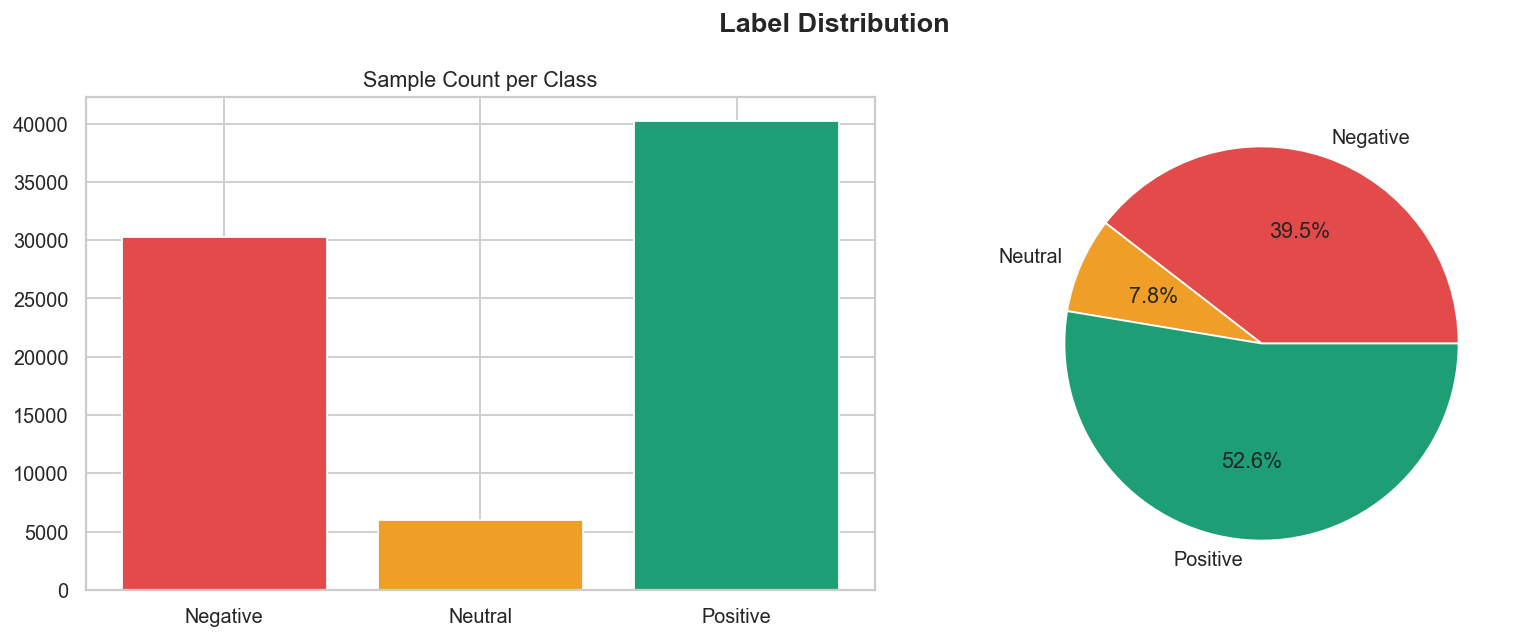

C:\Users\RITIK\AppData\Local\Temp\ipykernel_14112\4157931962.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="word_count", data=df, palette=LABEL_COLORS, ax=axes[0])
C:\Users\RITIK\AppData\Local\Temp\ipykernel_14112\4157931962.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label_name", y="word_count", data=df, palette=LABEL_COLORS, ax=axes[1])


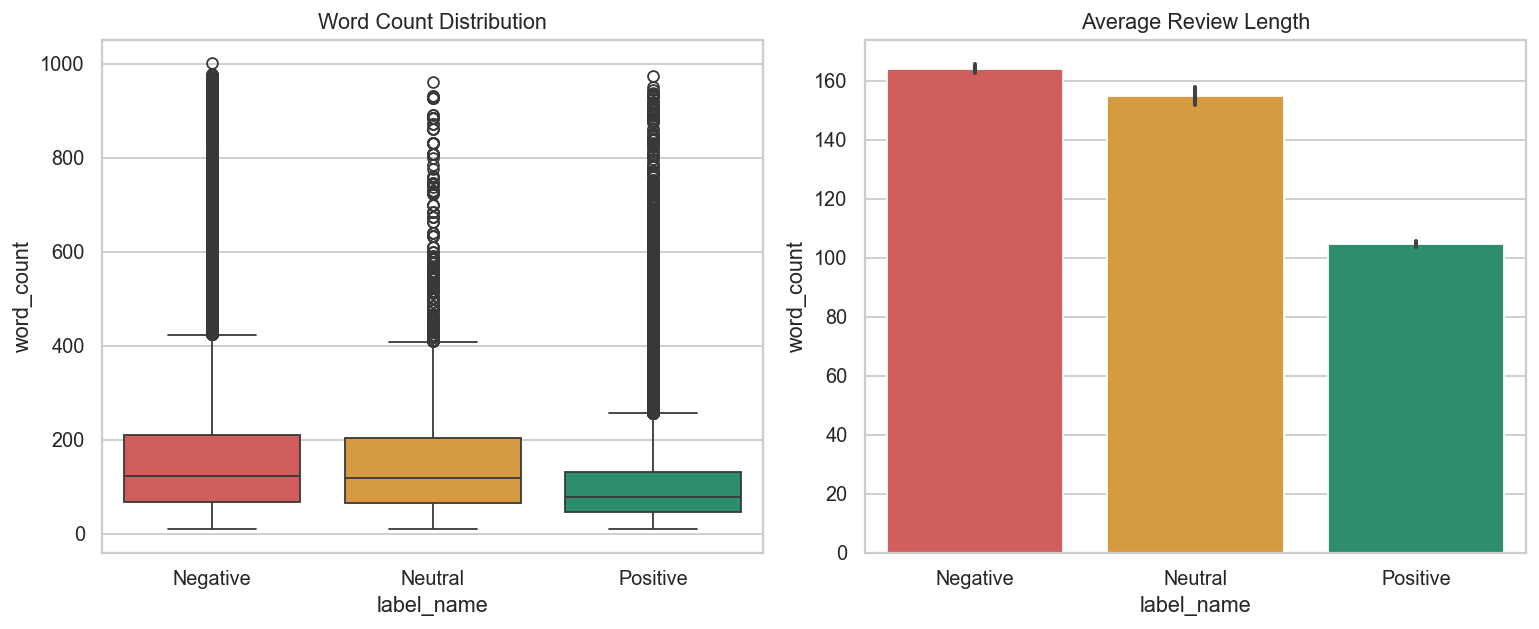

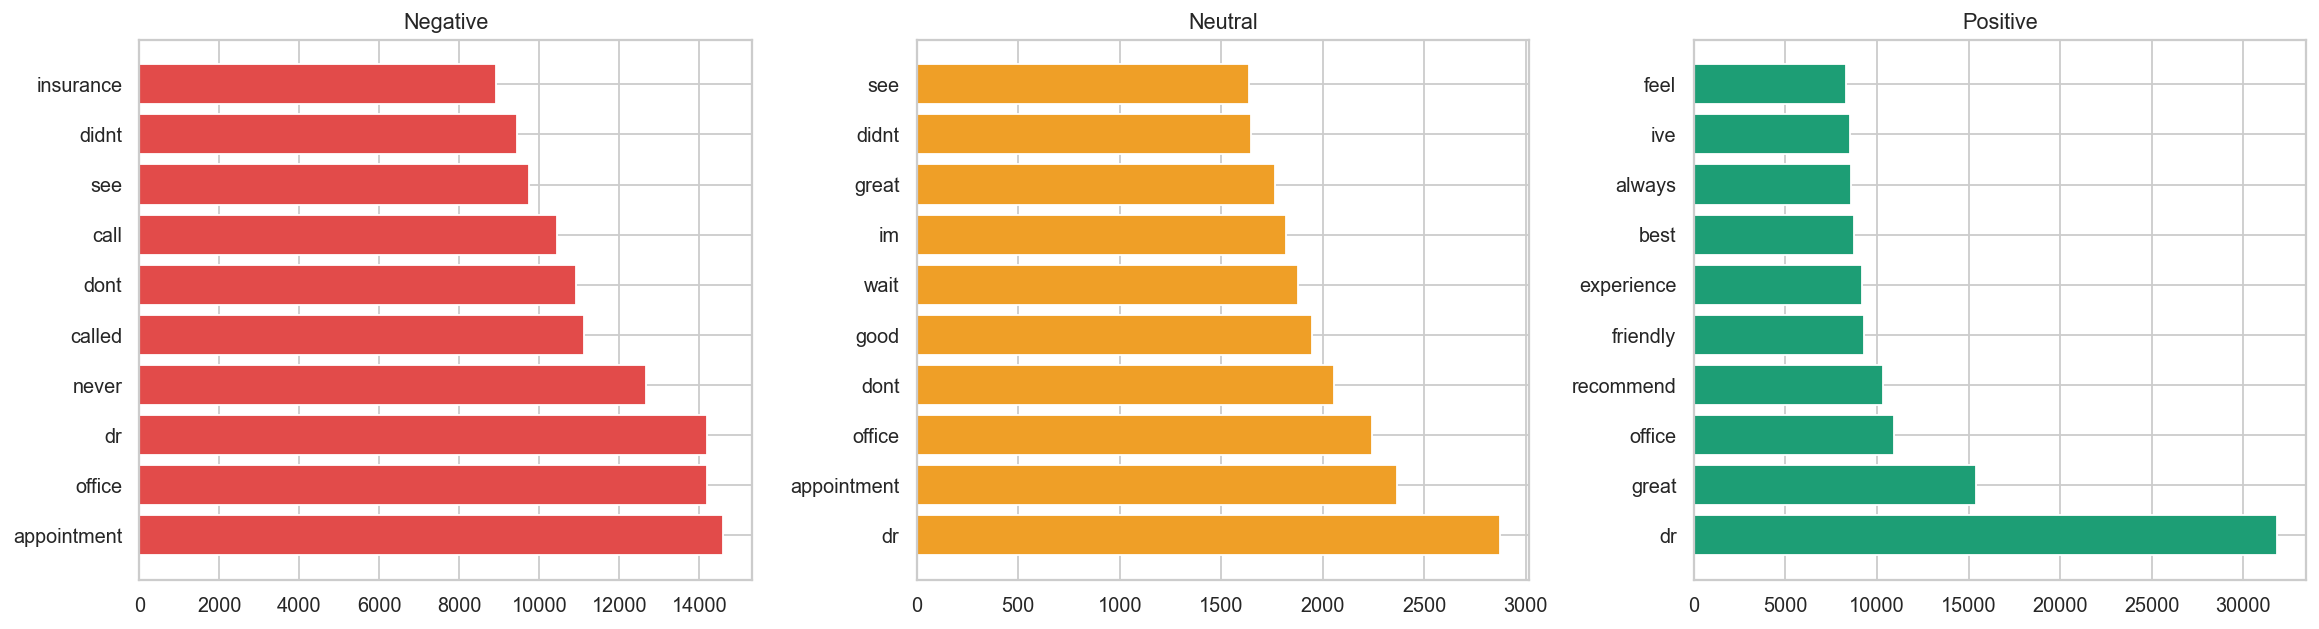

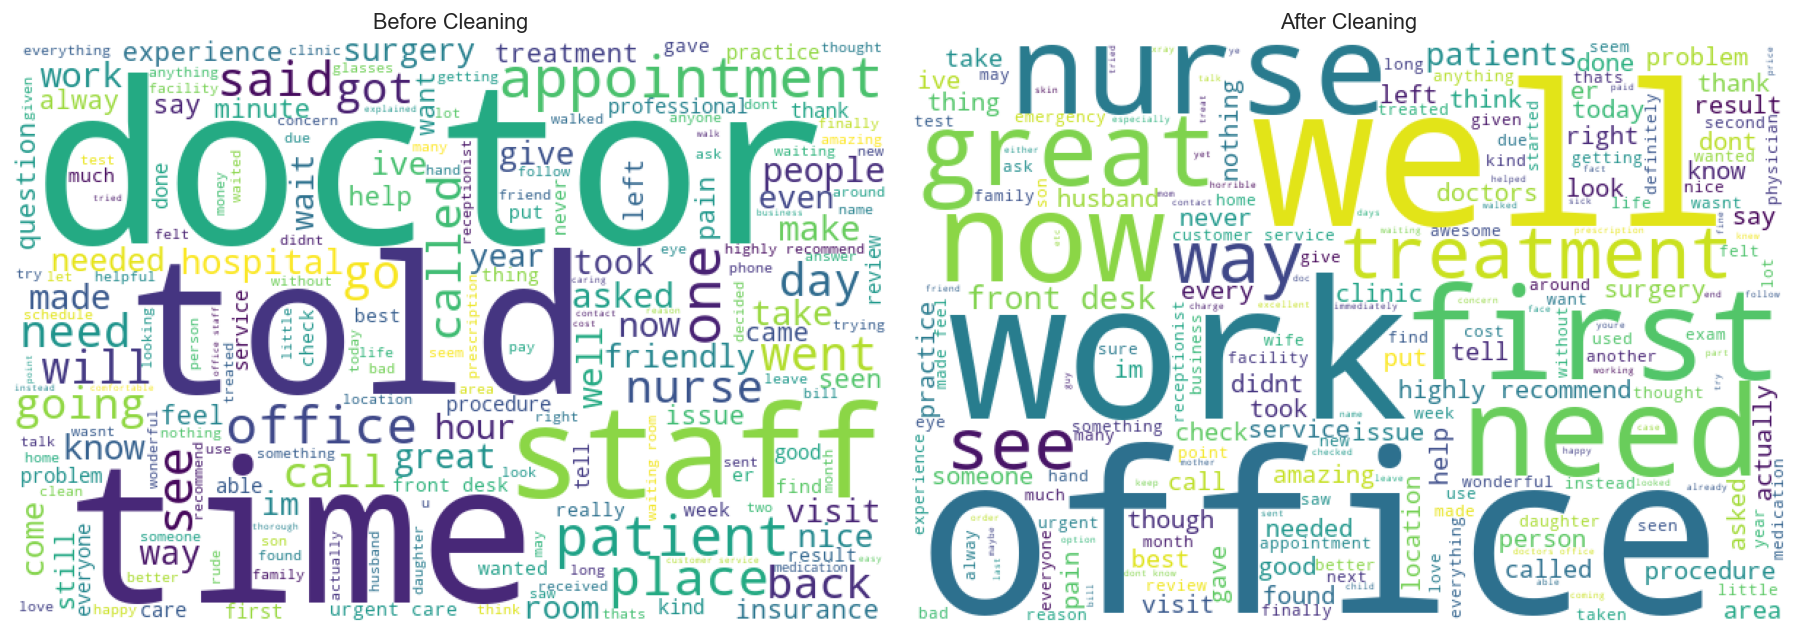


🎉 EDA COMPLETE with PREPROCESSING COMPARISON


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
import re

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
CSV_PATH    = "hospital_reviews_FINAL.csv"
TEXT_COL    = "Review Text"
LABEL_COL   = "Label"

LABEL_MAP   = {0: "Negative", 1: "Neutral", 2: "Positive"}
LABEL_COLORS= ["#E24B4A", "#EF9F27", "#1D9E75"]

CUSTOM_STOPWORDS = set(STOPWORDS) | {
    "hospital", "doctor", "staff", "patient", "care", "went", "go",
    "time", "said", "told", "one", "place", "room", "people", "day",
    "got", "get", "come", "came", "back", "would", "also", "even",
    "will", "still", "like", "just", "really", "going", "us", "make"
}

# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df[TEXT_COL] = df[TEXT_COL].astype(str)

# ─────────────────────────────────────────────
# TEXT CLEANING FUNCTION
# ─────────────────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in CUSTOM_STOPWORDS]
    return " ".join(words)

df["cleaned_text"] = df[TEXT_COL].apply(clean_text)

# Basic stats
df["word_count"] = df[TEXT_COL].str.split().str.len()
df["char_count"] = df[TEXT_COL].str.len()
df["label_name"] = df[LABEL_COL].map(LABEL_MAP)

# ─────────────────────────────────────────────
# 🔥 BEFORE vs AFTER TEXT (VERY IMPORTANT)
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("BEFORE vs AFTER PREPROCESSING")
print("="*60)

sample_df = df.sample(5, random_state=42)

for i, row in sample_df.iterrows():
    print("\n🔹 ORIGINAL:\n", row[TEXT_COL])
    print("🔸 CLEANED:\n", row["cleaned_text"])
    print("-"*60)

# ─────────────────────────────────────────────
# 🔥 WORD FREQUENCY COMPARISON
# ─────────────────────────────────────────────
print("\nTop words BEFORE cleaning:")
raw_words = " ".join(df[TEXT_COL]).lower().split()
print(Counter(raw_words).most_common(10))

print("\nTop words AFTER cleaning:")
clean_words = []
for t in df["cleaned_text"]:
    clean_words.extend(t.split())
print(Counter(clean_words).most_common(10))

# ─────────────────────────────────────────────
# FIG 1 — LABEL DISTRIBUTION
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Label Distribution", fontsize=15, fontweight="bold")

counts = df[LABEL_COL].value_counts().sort_index()
labels = [LABEL_MAP.get(i, str(i)) for i in counts.index]

# Bar
bars = axes[0].bar(labels, counts.values, color=LABEL_COLORS)
axes[0].set_title("Sample Count per Class")

# Pie
axes[1].pie(counts.values, labels=labels, colors=LABEL_COLORS, autopct="%1.1f%%")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# FIG 2 — REVIEW LENGTH
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="label_name", y="word_count", data=df, palette=LABEL_COLORS, ax=axes[0])
axes[0].set_title("Word Count Distribution")

sns.barplot(x="label_name", y="word_count", data=df, palette=LABEL_COLORS, ax=axes[1])
axes[1].set_title("Average Review Length")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# FIG 3 — TOP WORDS PER CLASS (CLEANED)
# ─────────────────────────────────────────────
def top_words(texts, n=10):
    words = []
    for t in texts:
        words.extend(t.split())
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (label_id, label_name) in enumerate(LABEL_MAP.items()):
    subset = df[df[LABEL_COL] == label_id]["cleaned_text"]
    top = top_words(subset)
    
    if top:
        words, freqs = zip(*top)
        axes[i].barh(words, freqs, color=LABEL_COLORS[i])
        axes[i].set_title(label_name)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 🔥 WORDCLOUD — BEFORE vs AFTER
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE
wc_raw = WordCloud(width=600, height=400, background_color="white").generate(
    " ".join(df[TEXT_COL])
)
axes[0].imshow(wc_raw)
axes[0].set_title("Before Cleaning")
axes[0].axis("off")

# AFTER
wc_clean = WordCloud(width=600, height=400, background_color="white").generate(
    " ".join(df["cleaned_text"])
)
axes[1].imshow(wc_clean)
axes[1].set_title("After Cleaning")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# FINAL MESSAGE
# ─────────────────────────────────────────────
print("\n🎉 EDA COMPLETE with PREPROCESSING COMPARISON")

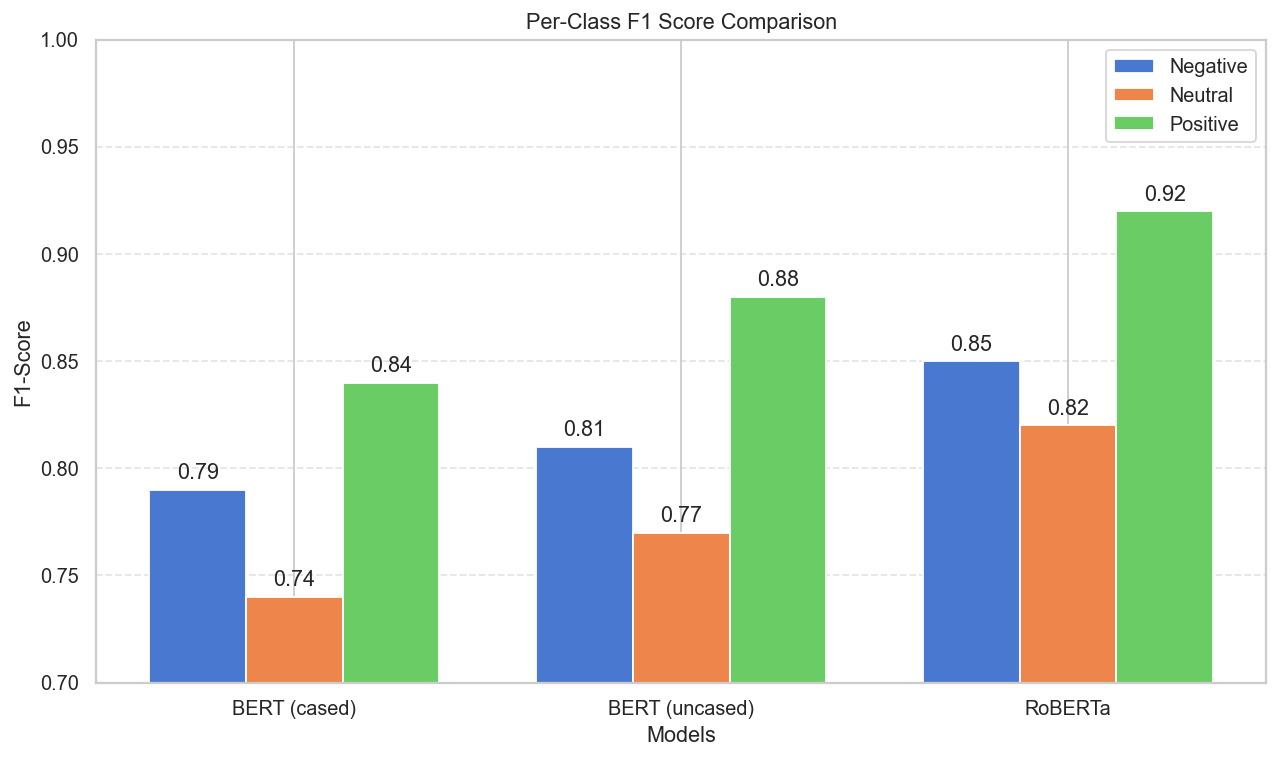

✅ Saved → f1_per_class.png


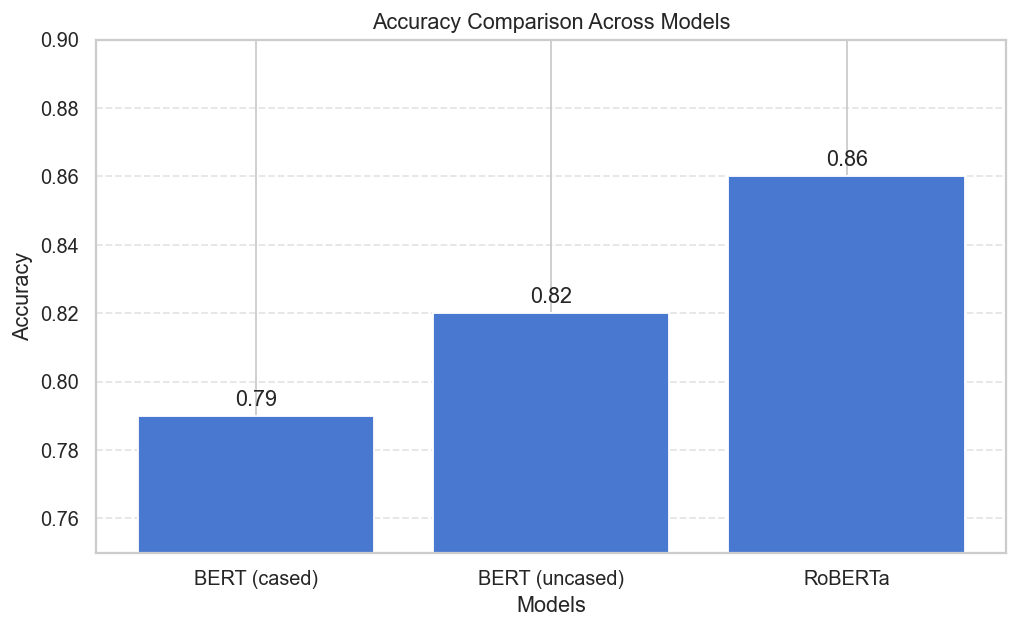

✅ Saved → accuracy_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────
# DATA
# ─────────────────────────────────────────────
models = ["BERT (cased)", "BERT (uncased)", "RoBERTa"]

negative = [0.79, 0.81, 0.85]
neutral  = [0.74, 0.77, 0.82]
positive = [0.84, 0.88, 0.92]

accuracy = [0.79, 0.82, 0.86]

x = np.arange(len(models))
width = 0.25

# ─────────────────────────────────────────────
# 🔹 GRAPH 1: F1 PER CLASS
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))

plt.bar(x - width, negative, width, label="Negative")
plt.bar(x,         neutral,  width, label="Neutral")
plt.bar(x + width, positive, width, label="Positive")

plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.title("Per-Class F1 Score Comparison")
plt.xticks(x, models)
plt.ylim(0.7, 1.0)

# Value labels
for i in range(len(models)):
    plt.text(x[i] - width, negative[i] + 0.005, f"{negative[i]:.2f}", ha='center')
    plt.text(x[i],         neutral[i] + 0.005,  f"{neutral[i]:.2f}", ha='center')
    plt.text(x[i] + width, positive[i] + 0.005, f"{positive[i]:.2f}", ha='center')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("f1_per_class.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved → f1_per_class.png")


# ─────────────────────────────────────────────
# 🔹 GRAPH 2: ACCURACY
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 5))

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Models")
plt.ylim(0.75, 0.9)

# Value labels
for i in range(len(models)):
    plt.text(i, accuracy[i] + 0.003, f"{accuracy[i]:.2f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved → accuracy_comparison.png")